# 🌤️ Predicción de Temperatura - Weather ML Notebook
Este notebook te permite analizar los datos climáticos y entrenar modelos para predecir temperatura futura.

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar datos
df = pd.read_csv("weather_data.csv")
df["timestamp"] = pd.to_datetime(df["timestamp"], errors="coerce")
df = df.dropna(subset=["timestamp"])
df.sort_values("timestamp", inplace=True)
df.drop_duplicates("timestamp", inplace=True)

df.tail()

,timestamp,temperature,dew_point,humidity,wind_speed,pressure,uv_index,hour,dayofweek,minute,pred_temp_plus_1h,pred_temp_plus_3h
78,2025-06-01 19:28:48.601677,60,48,64,8.51,29.77,0.9,NaN,NaN,NaN,NaN,NaN
79,2025-06-01 19:28:58.607647,60,48,64,8.51,29.77,0.9,NaN,NaN,NaN,NaN,NaN
80,2025-06-01 19:29:08.610730,60,48,64,8.51,29.77,0.9,NaN,NaN,NaN,NaN,NaN
81,2025-06-01 19:29:18.608971,60,48,64,8.51,29.77,0.9,NaN,NaN,NaN,NaN,NaN
82,2025-06-01 19:29:28.613672,60,48,64,8.51,29.77,0.9,NaN,NaN,NaN,NaN,NaN


## 📊 Visualización de variables

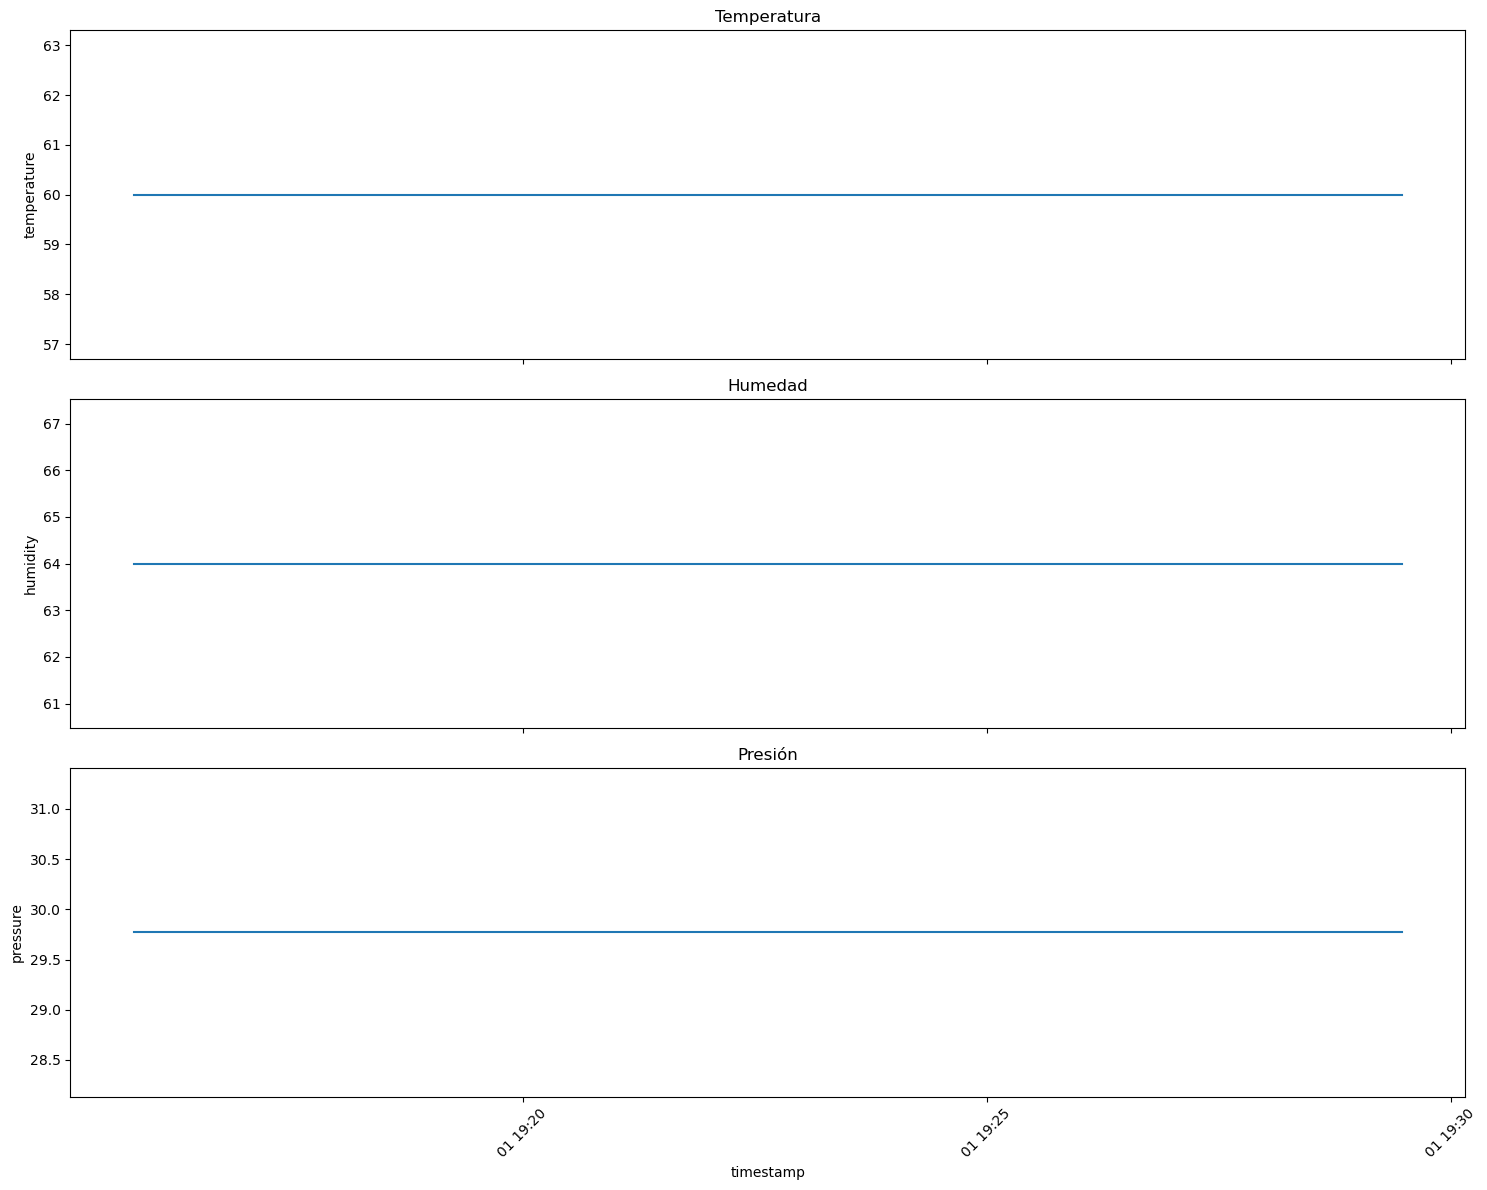

In [11]:
fig, ax = plt.subplots(3, 1, figsize=(15, 12), sharex=True)
sns.lineplot(data=df, x="timestamp", y="temperature", ax=ax[0]).set(title="Temperatura")
sns.lineplot(data=df, x="timestamp", y="humidity", ax=ax[1]).set(title="Humedad")
sns.lineplot(data=df, x="timestamp", y="pressure", ax=ax[2]).set(title="Presión")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## 🔮 Entrenamiento de modelo para predecir temperatura futura (+1h)

In [12]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import joblib

# Crear columna objetivo: temperatura 1h después
df["temp_plus_1h"] = df["temperature"].shift(-1)

# Eliminar filas con NaN
df_model = df.dropna(subset=["temp_plus_1h"])
X = df_model[["temperature", "humidity", "dew_point", "wind_speed", "pressure", "uv_index"]]
y = df_model["temp_plus_1h"]

# Separar datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# Entrenar modelo
model = DecisionTreeRegressor()
model.fit(X_train, y_train)

# Evaluar
y_pred = model.predict(X_test)
print("MSE:", mean_squared_error(y_test, y_pred))

# Guardar modelo
joblib.dump(model, "modelo_temp_plus_1h_entrenado.ipynb.pkl")


MSE: 0.0


['modelo_temp_plus_1h_entrenado.ipynb.pkl']